# TabNet: Transfer Learning for Himalayan Ground Motion
- Load Himalayan + NGA-West data
- Standardize columns & Vs30 mapping
- Clean & preprocess identically
- Prepare for transfer learning

In [ ]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — All parameters in one place
# ══════════════════════════════════════════════════════════════════════════════
# ── Files & Paths ─────────────────────────────────────────────────────────────
NGA_FILE = 'dataset/Updated_NGA_West2_Flatfile_RotD50_d050_public_version.xlsx'
HIM_FILE = 'dataset/HimData-2.csv'
OUTPUT_DIR = 'results/tabnet-himalaya'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Random Seed ───────────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── VS30 Mapping (Soil Class → Continuous Value) ──────────────────────────────
VS30_MAP = {'A': 1500, 'B': 760, 'C': 360}  # NEHRP soil classification

# ── Train/Test Parameters ─────────────────────────────────────────────────────
TEST_SIZE = 0.15         # Fraction of data for test set
VAL_FRAC = 0.15          # Fraction of training data for validation

# ── TabNet Best Config (from tabnet.ipynb hyperparameter search) ───────────────
BEST_CONFIG = {
    'n_d':           64,            # Decision step embedding width
    'n_steps':       3,             # Number of sequential attention steps
    'momentum':      0.01,          # Batch norm momentum
    'lambda_sparse': 0.001,         # Sparsity regularization strength
    'lr':            0.003,         # Adam learning rate
    'batch_size':    256,           # Mini-batch size
}

# ── Training Parameters ───────────────────────────────────────────────────────
MAX_EPOCHS = 300        # Maximum epochs for final training
PATIENCE = 50           # Early stopping patience


# Transfer Learning Parameters (Option A: Fine-tuning with low LR) ─────────
LAST_N_LAYERS_TO_UNFREEZE = 5  # Number of final layers to unfreeze for fine-tuning
# ── Helper function ───────────────────────────────────────────────────────────
def period_to_float(col):
    return float(col[1:-1])

print("✓ CONFIG loaded")
print(f"  Random Seed: {RANDOM_SEED}")
print(f"  Output Dir: {OUTPUT_DIR}")
print(f"  Best Config: n_d={BEST_CONFIG['n_d']}, n_steps={BEST_CONFIG['n_steps']}, lr={BEST_CONFIG['lr']:.0e}")

✓ CONFIG loaded
  Random Seed: 42
  Output Dir: results/tabnet-himalaya
  Best Config: n_d=32, n_steps=3, lr=3e-03


In [ ]:
# Load Himalayan data
him_df = pd.read_csv(HIM_FILE)

# Rename to match NGA columns
him_df = him_df.rename(columns={
    'Magnitude': 'Earthquake Magnitude',
    'Joyner_Boore_Rjb': 'Joyner-Boore Dist. (km)',
    'Fault_Mechanisc': 'Mechanism Based on Rake Angle',  # Fix typo
    'PGA': 'PGA (g)'
})

# Map Vs30: soil class → continuous (strip whitespace to be safe)
him_df['Soil_site_class'] = him_df['Soil_site_class'].str.strip()
him_df['Vs30 (m/s) selected for analysis'] = him_df['Soil_site_class'].map(VS30_MAP)

print(f"Himalayan loaded: {him_df.shape}")

Himalayan loaded: (773, 37)


In [ ]:
# Load NGA-West data
df_temp = pd.read_excel(NGA_FILE, engine='calamine', nrows=0)
period_cols = [c for c in df_temp.columns if c.startswith('T') and c.endswith('S')]
sa_cols = sorted([c for c in period_cols if period_to_float(c) <= 4.0], key=period_to_float)

cols_to_load = [
    'Earthquake Magnitude', 'Joyner-Boore Dist. (km)', 'Vs30 (m/s) selected for analysis',
    'Mechanism Based on Rake Angle', 'PGA (g)', 'PGV (cm/sec)'
] + sa_cols

nga_df = pd.read_excel(NGA_FILE, engine='calamine', usecols=cols_to_load)
print(f"NGA-West loaded: {nga_df.shape}")

NGA-West loaded: (21540, 96)


In [ ]:
# Find common periods (present in both datasets, ≤ 4s)
him_periods = ['T0.010S', 'T0.020S', 'T0.030S', 'T0.040S', 'T0.050S', 'T0.060S',
               'T0.070S', 'T0.080S', 'T0.090S', 'T0.100S', 'T0.150S', 'T0.200S',
               'T0.250S', 'T0.300S', 'T0.400S', 'T0.500S', 'T0.800S', 'T1.000S',
               'T1.200S', 'T1.500S', 'T1.800S', 'T2.000S', 'T2.500S', 'T3.000S',
               'T3.500S', 'T4.000S', 'T5.000S']

common_periods = sorted(set(him_periods) & set(sa_cols), key=period_to_float)
print(f"\nCommon periods: {len(common_periods)}")
print(f"  {common_periods}")


Common periods: 26
  ['T0.010S', 'T0.020S', 'T0.030S', 'T0.040S', 'T0.050S', 'T0.060S', 'T0.070S', 'T0.080S', 'T0.090S', 'T0.100S', 'T0.150S', 'T0.200S', 'T0.250S', 'T0.300S', 'T0.400S', 'T0.500S', 'T0.800S', 'T1.000S', 'T1.200S', 'T1.500S', 'T1.800S', 'T2.000S', 'T2.500S', 'T3.000S', 'T3.500S', 'T4.000S']


In [ ]:
# Clean and preprocess (same as tabnet.ipynb)
def clean_and_preprocess(df, periods):
    """Remove negatives/NaN/Inf, compute log transforms. NO PGV (missing in Himalayan)."""
    df = df.copy()
    
    # Don't include PGV - it's missing in Himalayan data
    base_cols = ['Earthquake Magnitude', 'Joyner-Boore Dist. (km)',
                 'Vs30 (m/s) selected for analysis', 'Mechanism Based on Rake Angle',
                 'PGA (g)'] + periods
    
    # Remove negatives
    for col in base_cols:
        df = df[df[col] >= 0]
    
    # Remove NaN/Inf
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=base_cols)
    df = df.reset_index(drop=True)
    
    # Log transforms
    df['log10_Rjb']  = np.log10(df['Joyner-Boore Dist. (km)'])
    df['log10_Vs30'] = np.log10(df['Vs30 (m/s) selected for analysis'])
    df['log10_PGA'] = np.log10(df['PGA (g)'])
    
    for col in periods:
        df[f'log10_{col}'] = np.log10(df[col])
    
    # Remove any rows with inf/nan after log transform
    all_log_cols = ['log10_Rjb', 'log10_Vs30', 'log10_PGA'] + [f'log10_{col}' for col in periods]
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=all_log_cols)
    df = df.reset_index(drop=True)
    
    return df

# Clean both
him_clean = clean_and_preprocess(him_df, common_periods)
nga_clean = clean_and_preprocess(nga_df, common_periods)

print(f"\nAfter cleaning:")
print(f"  Himalayan: {him_df.shape} → {him_clean.shape}")
print(f"  NGA-West:  {nga_df.shape} → {nga_clean.shape}")


After cleaning:
  Himalayan: (773, 37) → (754, 66)
  NGA-West:  (21540, 96) → (21230, 125)


/home/prem/miniconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
# Define input/output columns
input_cols = [
    'Earthquake Magnitude', 'Joyner-Boore Dist. (km)',
    'Mechanism Based on Rake Angle', 'Vs30 (m/s) selected for analysis',
    'log10_Vs30', 'log10_Rjb'
]

# Output: PGA + common spectral periods (NO PGV - missing in Himalayan)
output_cols = ['log10_PGA'] + [f'log10_{col}' for col in common_periods]

print(f"\nInputs:  {len(input_cols)} features")
print(f"Outputs: {len(output_cols)} targets (PGA + {len(common_periods)} periods)")

# Verify both have same structure
assert list(him_clean[input_cols].columns) == list(nga_clean[input_cols].columns)
assert list(him_clean[output_cols].columns) == list(nga_clean[output_cols].columns)
print("✓ Identical structure")


Inputs:  6 features
Outputs: 27 targets (PGA + 26 periods)
✓ Identical structure


In [ ]:
print(f"{'='*60}")
print(f"SUMMARY")
print(f"{'='*60}")
print(f"\nHIMALAYAN ({len(him_clean):,} records):")
print(f"  Raw → Cleaned: {len(him_df)} → {len(him_clean)}")
print(f"  Inputs:  {him_clean[input_cols].shape}")
print(f"  Outputs: {him_clean[output_cols].shape}")

print(f"\nNGA-WEST ({len(nga_clean):,} records):")
print(f"  Raw → Cleaned: {len(nga_df)} → {len(nga_clean)}")
print(f"  Inputs:  {nga_clean[input_cols].shape}")
print(f"  Outputs: {nga_clean[output_cols].shape}")

print(f"\nCOMMON PERIODS: {len(common_periods)}")
print(f"  {common_periods}")

print(f"\nOUTPUTS: {len(output_cols)} targets")
print(f"  - PGA (log10)")
print(f"  - {len(common_periods)} Spectral Periods (log10)")
print(f"  NOTE: PGV excluded (not present in Himalayan data)")

SUMMARY

HIMALAYAN (754 records):
  Raw → Cleaned: 773 → 754
  Inputs:  (754, 6)
  Outputs: (754, 27)

NGA-WEST (21,230 records):
  Raw → Cleaned: 21540 → 21230
  Inputs:  (21230, 6)
  Outputs: (21230, 27)

COMMON PERIODS: 26
  ['T0.010S', 'T0.020S', 'T0.030S', 'T0.040S', 'T0.050S', 'T0.060S', 'T0.070S', 'T0.080S', 'T0.090S', 'T0.100S', 'T0.150S', 'T0.200S', 'T0.250S', 'T0.300S', 'T0.400S', 'T0.500S', 'T0.800S', 'T1.000S', 'T1.200S', 'T1.500S', 'T1.800S', 'T2.000S', 'T2.500S', 'T3.000S', 'T3.500S', 'T4.000S']

OUTPUTS: 27 targets
  - PGA (log10)
  - 26 Spectral Periods (log10)
  NOTE: PGV excluded (not present in Himalayan data)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import importlib.util
import subprocess
import sys

# Install dependencies if needed
dependencies = {
    'pytorch_tabnet': 'pytorch-tabnet',
}

for module, package in dependencies.items():
    if importlib.util.find_spec(module) is None:
        print(f"📦 {package} not found. Installing...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
    else:
        print(f"✅ {package} is already installed.")

from pytorch_tabnet.tab_model import TabNetRegressor

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n✓ PyTorch version: {torch.__version__}")
print(f"✓ Device: {device}")
if device.type == 'cuda':
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✓ VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("⚠️  No GPU detected")

print("✓ All imports successful")

✅ pytorch-tabnet is already installed.

✓ PyTorch version: 2.6.0+cu124
✓ Device: cuda
✓ GPU: NVIDIA GeForce RTX 3050 Laptop GPU
✓ VRAM: 4.0 GB
✓ All imports successful


In [ ]:
print("="*70)
print("TRAIN/TEST SPLIT & SCALING")
print("="*70)

# Use NGA-West data as source for training (before transfer learning to Himalayan)
X = nga_clean[input_cols].values.astype('float32')
y = nga_clean[output_cols].values.astype('float32')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED)

print(f"\nOriginal NGA-West: {X.shape[0]:,} samples")
print(f"  Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

# Scale features and targets
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# Validation split (for early stopping during training)
n_val_split = int(len(X_train_scaled) * VAL_FRAC)
X_train_tr = X_train_scaled[n_val_split:]
y_train_tr = y_train_scaled[n_val_split:]
X_train_val = X_train_scaled[:n_val_split]
y_train_val = y_train_scaled[:n_val_split]

print(f"\nScaled training: {X_train_tr.shape[0]:,}  |  Validation: {X_train_val.shape[0]:,}")
print(f"X shape: {X_train_scaled.shape}  |  y shape: {y_train_scaled.shape}")

# Extract spectral periods for downstream use
sa_periods = np.array([period_to_float(col) for col in common_periods])
output_dim = len(output_cols)

print(f"\nInput features: {len(input_cols)}")
print(f"Output targets: {output_dim} (PGA + {len(common_periods)} SA periods)")
print("="*70)

TRAIN/TEST SPLIT & SCALING

Original NGA-West: 21,230 samples
  Train: 16,984  |  Test: 4,246

Scaled training: 14,437  |  Validation: 2,547
X shape: (16984, 6)  |  y shape: (16984, 27)

Input features: 6
Output targets: 27 (PGA + 26 SA periods)


In [ ]:
print("="*70)
print("TRAINING SOURCE MODEL (NGA-WEST)")
print("="*70)
print(f"\nConfig:")
print(f"  n_d={BEST_CONFIG['n_d']}, n_a={BEST_CONFIG['n_d']}, n_steps={BEST_CONFIG['n_steps']}")
print(f"  lr={BEST_CONFIG['lr']:.0e}, batch_size={BEST_CONFIG['batch_size']}")
print(f"  momentum={BEST_CONFIG['momentum']}, λ_sparse={BEST_CONFIG['lambda_sparse']:.0e}")
print(f"  max_epochs={MAX_EPOCHS}, patience={PATIENCE}")
print("="*70)

# Create and train TabNet model with best config
source_model = TabNetRegressor(
    n_d              = BEST_CONFIG['n_d'],
    n_a              = BEST_CONFIG['n_d'],
    n_steps          = BEST_CONFIG['n_steps'],
    momentum         = BEST_CONFIG['momentum'],
    lambda_sparse    = BEST_CONFIG['lambda_sparse'],
    optimizer_params = {'lr': BEST_CONFIG['lr']},
    seed             = RANDOM_SEED,
    device_name      = 'auto',
    verbose          = 1,
)

print("\nTraining...")
source_model.fit(
    X_train_tr, y_train_tr,
    eval_set           = [(X_train_val, y_train_val)],
    eval_metric        = ['mse'],
    max_epochs         = MAX_EPOCHS,
    patience           = PATIENCE,
    batch_size         = BEST_CONFIG['batch_size'],
    virtual_batch_size = max(8, BEST_CONFIG['batch_size'] // 4),
    drop_last          = False,
)

# Get best epoch info
best_val_mse = min(source_model.history['val_0_mse'])
best_epoch = source_model.history['val_0_mse'].index(best_val_mse)
total_epochs = len(source_model.history['loss'])

print(f"\n✓ Training complete")
print(f"  Best val MSE: {best_val_mse:.6f}  at epoch {best_epoch + 1}")
print(f"  Total epochs: {total_epochs}")

# Save model
model_path = f'{OUTPUT_DIR}/source_model_tabnet'
source_model.save_model(model_path)
print(f"✓ Model saved: {model_path}.zip")

TRAINING SOURCE MODEL (NGA-WEST)

Config:
  n_d=32, n_a=32, n_steps=3
  lr=3e-03, batch_size=256
  momentum=0.01, λ_sparse=1e-03
  max_epochs=200, patience=15

Training...


/home/prem/miniconda3/lib/python3.13/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.06719 | val_0_mse: 0.31122 |  0:00:03s
epoch 1  | loss: 0.24154 | val_0_mse: 0.18965 |  0:00:05s
epoch 2  | loss: 0.19077 | val_0_mse: 0.16279 |  0:00:06s
epoch 3  | loss: 0.16499 | val_0_mse: 0.14399 |  0:00:08s
epoch 4  | loss: 0.15535 | val_0_mse: 0.13451 |  0:00:10s
epoch 5  | loss: 0.14352 | val_0_mse: 0.12996 |  0:00:11s
epoch 6  | loss: 0.13867 | val_0_mse: 0.13173 |  0:00:12s
epoch 7  | loss: 0.13453 | val_0_mse: 0.12407 |  0:00:14s
epoch 8  | loss: 0.13228 | val_0_mse: 0.12117 |  0:00:15s
epoch 9  | loss: 0.13113 | val_0_mse: 0.11929 |  0:00:17s
epoch 10 | loss: 0.12677 | val_0_mse: 0.11969 |  0:00:19s
epoch 11 | loss: 0.1249  | val_0_mse: 0.11782 |  0:00:21s
epoch 12 | loss: 0.12482 | val_0_mse: 0.12247 |  0:00:22s
epoch 13 | loss: 0.12346 | val_0_mse: 0.11751 |  0:00:24s
epoch 14 | loss: 0.11917 | val_0_mse: 0.11554 |  0:00:26s
epoch 15 | loss: 0.121   | val_0_mse: 0.1177  |  0:00:27s
epoch 16 | loss: 0.11941 | val_0_mse: 0.11975 |  0:00:30s
epoch 17 | los

/home/prem/miniconda3/lib/python3.13/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



✓ Training complete
  Best val MSE: 0.102999  at epoch 78
  Total epochs: 93
Successfully saved model at results/tabnet-himalaya/source_model_tabnet.zip
✓ Model saved: results/tabnet-himalaya/source_model_tabnet.zip



TRAINING LOSS VISUALIZATION


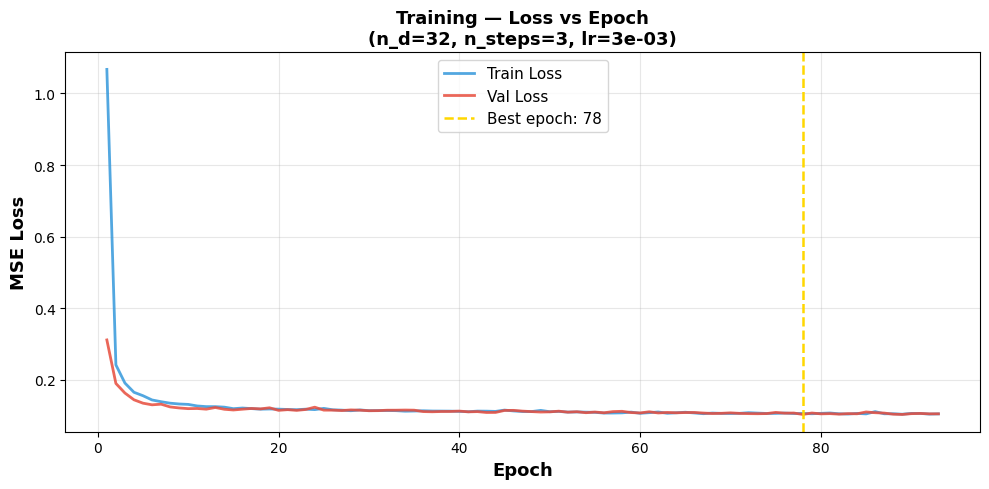

✓ Saved: results/tabnet-himalaya/source_model_training_loss.png


In [ ]:
print("\n" + "="*70)
print("TRAINING LOSS VISUALIZATION")
print("="*70)

train_losses = source_model.history['loss']
val_losses = source_model.history['val_0_mse']
epochs_range = range(1, len(train_losses) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs_range, train_losses, label='Train Loss', color='#3498DB', linewidth=2, alpha=0.85)
ax.plot(epochs_range, val_losses, label='Val Loss', color='#E74C3C', linewidth=2, alpha=0.85)
ax.axvline(best_epoch + 1, color='gold', linestyle='--', linewidth=1.8, 
           label=f'Best epoch: {best_epoch + 1}')
ax.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax.set_ylabel('MSE Loss', fontsize=13, fontweight='bold')
ax.set_title(f'Training — Loss vs Epoch\n(n_d={BEST_CONFIG["n_d"]}, n_steps={BEST_CONFIG["n_steps"]}, lr={BEST_CONFIG["lr"]:.0e})',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/source_model_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/source_model_training_loss.png")

In [ ]:
print("="*70)
print("SOURCE MODEL EVALUATION (TEST SET)")
print("="*70)

# Predictions: scaled → log10 → original units
y_pred_scaled = source_model.predict(X_test_scaled)
y_pred_log = scaler_y.inverse_transform(y_pred_scaled)
y_true_log = scaler_y.inverse_transform(y_test_scaled)
y_pred_orig = 10 ** y_pred_log
y_true_orig = 10 ** y_true_log

# Residuals in log10 space
residuals_log = y_true_log - y_pred_log

# Compute metrics per output
r2_per_output = [r2_score(y_true_log[:, i], y_pred_log[:, i]) for i in range(output_dim)]
mae_per_output = [mean_absolute_error(y_true_log[:, i], y_pred_log[:, i]) for i in range(output_dim)]
rmse_per_output = [np.sqrt(mean_squared_error(y_true_log[:, i], y_pred_log[:, i])) for i in range(output_dim)]

# Overall metrics
mae_overall = mean_absolute_error(y_true_log, y_pred_log)
mse_overall = mean_squared_error(y_true_log, y_pred_log)
rmse_overall = np.sqrt(mse_overall)
r2_overall = r2_score(y_true_log, y_pred_log)
mape_overall = float(np.mean(np.abs((y_true_orig - y_pred_orig) / (y_true_orig + 1e-12))) * 100)

print(f"\n{'Metric':<30}  {'Value':>12}")
print("-" * 47)
print(f"{'MAE  (log10 units)':<30}  {mae_overall:>12.6f}")
print(f"{'MSE  (log10 units)':<30}  {mse_overall:>12.6f}")
print(f"{'RMSE (log10 units)':<30}  {rmse_overall:>12.6f}")
print(f"{'R²   (overall)':<30}  {r2_overall:>12.6f}")
print(f"{'MAPE (original units, %)':<30}  {mape_overall:>12.4f}")
print("-" * 47)
print(f"\nPer-output statistics:")
print(f"  Mean R²  : {np.mean(r2_per_output):.6f}")
print(f"  Min  R²  : {np.min(r2_per_output):.6f}  (output {np.argmin(r2_per_output)} → {output_cols[np.argmin(r2_per_output)]})")
print(f"  Max  R²  : {np.max(r2_per_output):.6f}")
print(f"  Mean MAE : {np.mean(mae_per_output):.6f}")
print(f"  Mean RMSE: {np.mean(rmse_per_output):.6f}")

SOURCE MODEL EVALUATION (TEST SET)

Metric                                 Value
-----------------------------------------------
MAE  (log10 units)                  0.287977
MSE  (log10 units)                  0.138949
RMSE (log10 units)                  0.372759
R²   (overall)                      0.904224
MAPE (original units, %)             98.3653
-----------------------------------------------

Per-output statistics:
  Mean R²  : 0.904224
  Min  R²  : 0.871008  (output 8 → log10_T0.080S)
  Max  R²  : 0.943425
  Mean MAE : 0.287978
  Mean RMSE: 0.372221



R² PER OUTPUT


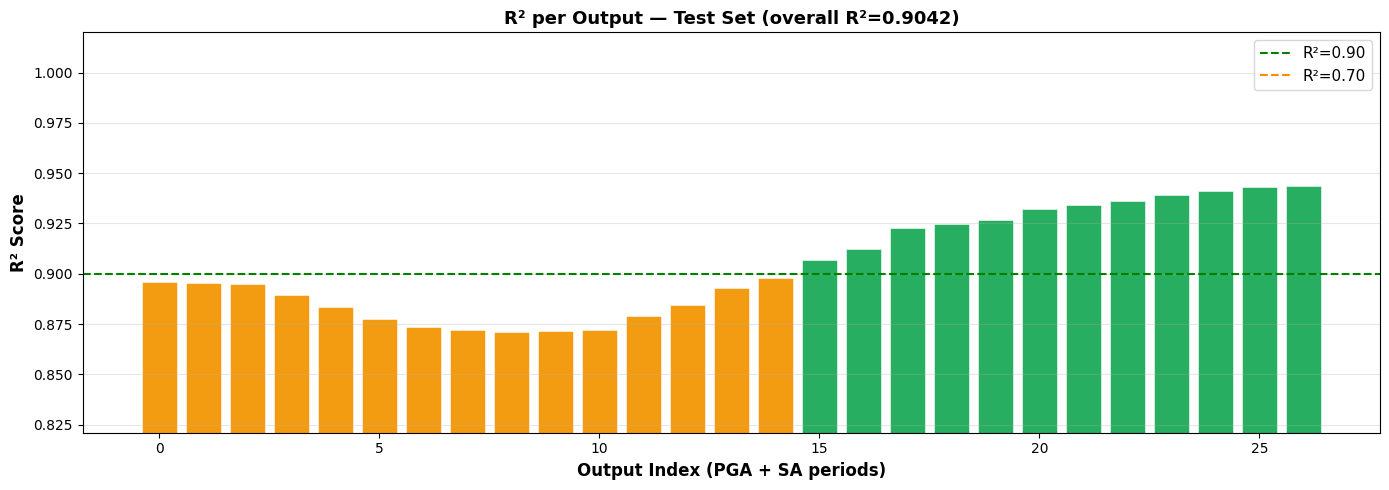

✓ Saved: results/tabnet-himalaya/source_model_r2_per_output.png


In [ ]:
print("\n" + "="*70)
print("R² PER OUTPUT")
print("="*70)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#27AE60' if v >= 0.9 else '#F39C12' if v >= 0.7 else '#E74C3C' for v in r2_per_output]
ax.bar(range(output_dim), r2_per_output, color=colors, edgecolor='white', linewidth=0.4)
ax.axhline(0.9, color='green', linestyle='--', linewidth=1.5, label='R²=0.90')
ax.axhline(0.7, color='darkorange', linestyle='--', linewidth=1.5, label='R²=0.70')
ax.set_xlabel('Output Index (PGA + SA periods)', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title(f'R² per Output — Test Set (overall R²={r2_overall:.4f})', fontsize=13, fontweight='bold')
ax.set_ylim(max(0, min(r2_per_output) - 0.05), 1.02)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/source_model_r2_per_output.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/source_model_r2_per_output.png")


PREDICTED vs OBSERVED — KEY OUTPUTS


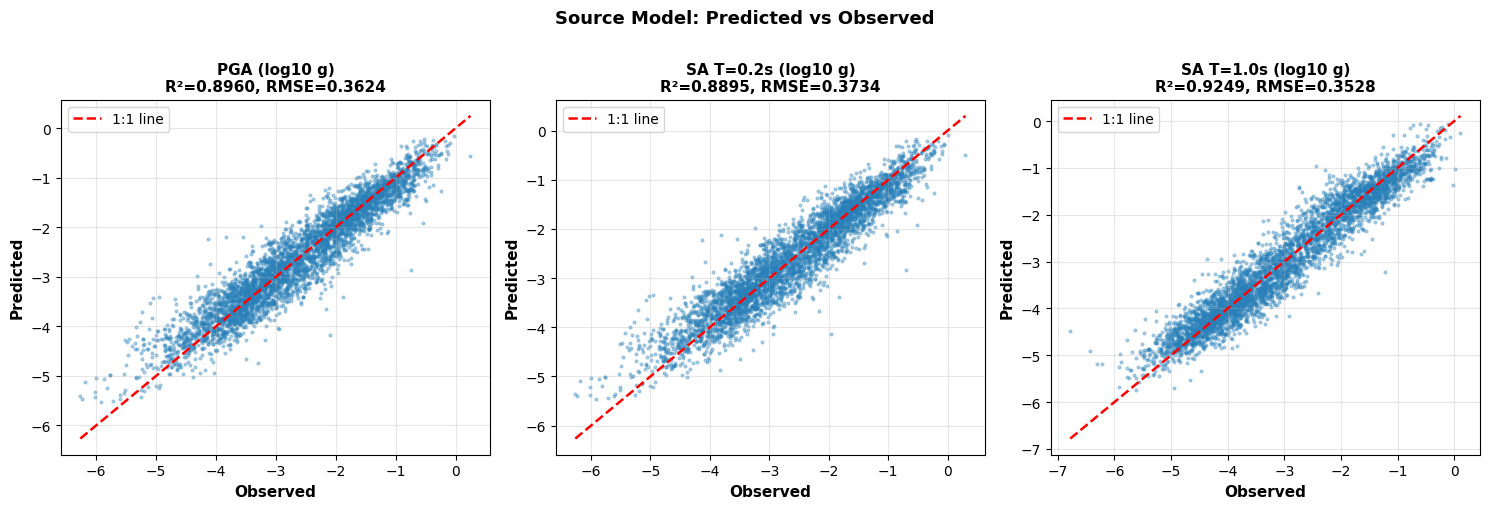

✓ Saved: results/tabnet-himalaya/source_model_pred_vs_obs.png


In [ ]:
print("\n" + "="*70)
print("PREDICTED vs OBSERVED — KEY OUTPUTS")
print("="*70)

# Find T=1.0s index
idx_sa1 = next((i for i, c in enumerate(output_cols) if 'T1.0' in c), min(output_dim - 1, 26))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['PGA (log10 g)', 'SA T=0.2s (log10 g)', 'SA T=1.0s (log10 g)']
indices = [0, 3, idx_sa1]  # PGA, ~0.2s, ~1.0s

for ax, idx, title in zip(axes, indices, titles):
    lo = min(y_true_log[:, idx].min(), y_pred_log[:, idx].min())
    hi = max(y_true_log[:, idx].max(), y_pred_log[:, idx].max())
    ax.scatter(y_true_log[:, idx], y_pred_log[:, idx], s=4, alpha=0.35, color='#2980B9', rasterized=True)
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.8, label='1:1 line')
    ax.set_xlabel('Observed', fontsize=11, fontweight='bold')
    ax.set_ylabel('Predicted', fontsize=11, fontweight='bold')
    ax.set_title(f'{title}\nR²={r2_per_output[idx]:.4f}, RMSE={rmse_per_output[idx]:.4f}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Source Model: Predicted vs Observed', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/source_model_pred_vs_obs.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/source_model_pred_vs_obs.png")


RESIDUAL ANALYSIS — PGA


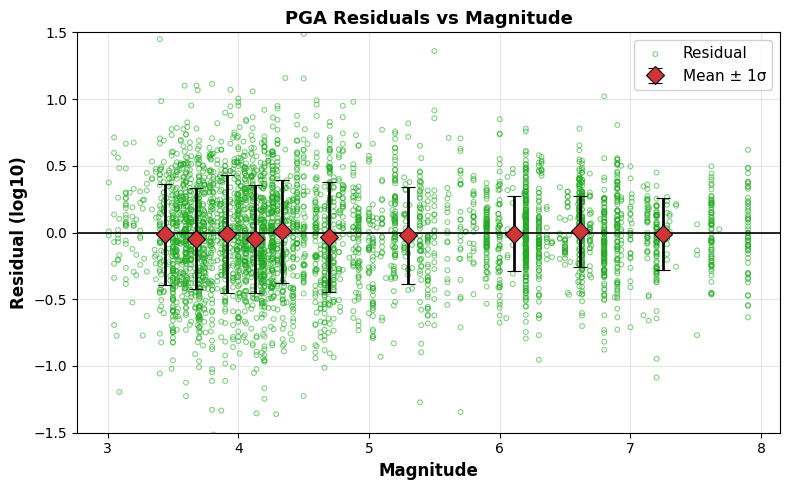

✓ Saved: results/tabnet-himalaya/source_model_residuals_magnitude.png


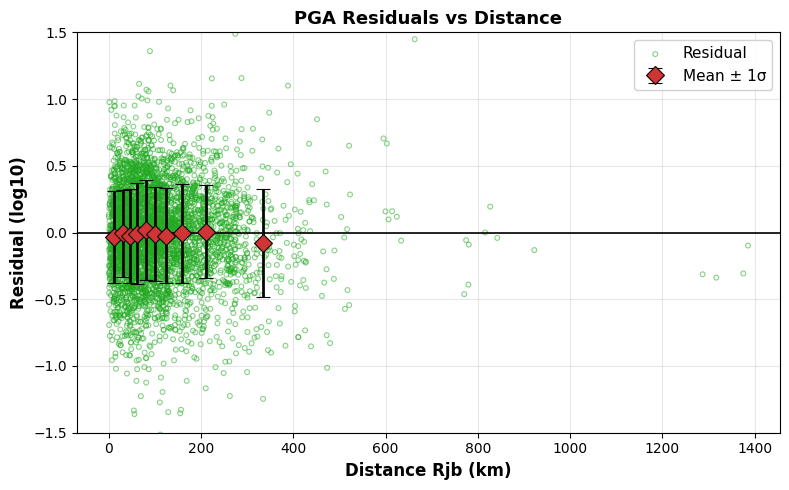

✓ Saved: results/tabnet-himalaya/source_model_residuals_distance.png

✓ Source model evaluation complete!
  Results saved to: results/tabnet-himalaya/


In [ ]:
print("\n" + "="*70)
print("RESIDUAL ANALYSIS — PGA")
print("="*70)

pga_resid = residuals_log[:, 0]
idx_mag = input_cols.index('Earthquake Magnitude')
idx_rjb = input_cols.index('Joyner-Boore Dist. (km)')

Mw = X_test[:, idx_mag].astype(float)
Rjb = X_test[:, idx_rjb].astype(float)

def equal_count_bins(x, y, n_bins=10, log_x=False):
    order = np.argsort(x)
    xs, ys = x[order], y[order]
    groups = np.array_split(np.arange(len(xs)), n_bins)
    centers, means, stds, counts = [], [], [], []
    for g in groups:
        if len(g) < 2:
            continue
        xg, yg = xs[g], ys[g]
        c = np.exp(np.mean(np.log(np.clip(xg, 1e-9, None)))) if log_x else np.mean(xg)
        centers.append(c)
        means.append(np.mean(yg))
        stds.append(np.std(yg, ddof=1))
        counts.append(len(g))
    return np.array(centers), np.array(means), np.array(stds), np.array(counts)

# PGA Residual vs Magnitude
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(Mw, pga_resid, s=12, facecolors='none', edgecolors='#22AA22', 
           linewidths=0.8, alpha=0.55, rasterized=True, zorder=2, label='Residual')
ax.axhline(0.0, color='black', linewidth=1.2, linestyle='-', zorder=3)
bc, bm, bs, _ = equal_count_bins(Mw, pga_resid, n_bins=10, log_x=False)
ax.errorbar(bc, bm, yerr=bs, fmt='D', color='#D13434', ecolor='#060606',
            elinewidth=2.0, capsize=5, capthick=2.0, markersize=9,
            markeredgecolor='#060606', markeredgewidth=0.8, linewidth=0, zorder=5, label='Mean ± 1σ')
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('Magnitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Residual (log10)', fontsize=12, fontweight='bold')
ax.set_title('PGA Residuals vs Magnitude', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/source_model_residuals_magnitude.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/source_model_residuals_magnitude.png")

# PGA Residual vs Distance
fig, ax = plt.subplots(figsize=(8, 5))
mask = Rjb > 0.1
ax.scatter(Rjb[mask], pga_resid[mask], s=12, facecolors='none', edgecolors='#22AA22',
           linewidths=0.8, alpha=0.55, rasterized=True, zorder=2, label='Residual')
ax.axhline(0.0, color='black', linewidth=1.2, linestyle='-', zorder=3)
bc, bm, bs, _ = equal_count_bins(Rjb[mask], pga_resid[mask], n_bins=10, log_x=False)
ax.errorbar(bc, bm, yerr=bs, fmt='D', color='#D13434', ecolor='#060606',
            elinewidth=2.0, capsize=5, capthick=2.0, markersize=9,
            markeredgecolor='#060606', markeredgewidth=0.8, linewidth=0, zorder=5, label='Mean ± 1σ')
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('Distance Rjb (km)', fontsize=12, fontweight='bold')
ax.set_ylabel('Residual (log10)', fontsize=12, fontweight='bold')
ax.set_title('PGA Residuals vs Distance', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/source_model_residuals_distance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {OUTPUT_DIR}/source_model_residuals_distance.png")

print("\n✓ Source model evaluation complete!")
print(f"  Results saved to: {OUTPUT_DIR}/")

In [ ]:
print("="*70)
print("HIMALAYAN TRAIN/TEST SPLIT (80-20) & SCALING")
print("="*70)
print("\n⚠️  NOTE: Using NGA-trained scalers (scaler_X, scaler_y)")
print("  This keeps Himalayan data in 'NGA feature space'")
print("="*70)

# Extract Himalayan data
X_him = him_clean[input_cols].values.astype('float32')
y_him = him_clean[output_cols].values.astype('float32')

print(f"\nHimalayan data: {X_him.shape[0]:,} samples")

# 80-20 train/test split
X_him_train, X_him_test, y_him_train, y_him_test = train_test_split(
    X_him, y_him, test_size=TEST_SIZE, random_state=RANDOM_SEED)

print(f"  Train: {X_him_train.shape[0]:,}  |  Test: {X_him_test.shape[0]:,}")

# ── APPLY NGA SCALERS (no refitting) ──────────────────────────────────────
X_him_train_scaled = scaler_X.transform(X_him_train)
X_him_test_scaled  = scaler_X.transform(X_him_test)

y_him_train_scaled = scaler_y.transform(y_him_train)
y_him_test_scaled  = scaler_y.transform(y_him_test)

print(f"\nScaled (using NGA scalers):")
print(f"  X_him_train: min={X_him_train_scaled.min():.4f}, max={X_him_train_scaled.max():.4f}, "
      f"mean={X_him_train_scaled.mean():.6f}, std={X_him_train_scaled.std():.6f}")
print(f"  y_him_train: min={y_him_train_scaled.min():.4f}, max={y_him_train_scaled.max():.4f}, "
      f"mean={y_him_train_scaled.mean():.6f}, std={y_him_train_scaled.std():.6f}")

# Validation split from Himalayan training set
n_him_val_split = int(len(X_him_train_scaled) * VAL_FRAC)
X_him_train_tr  = X_him_train_scaled[n_him_val_split:]
y_him_train_tr  = y_him_train_scaled[n_him_val_split:]
X_him_train_val = X_him_train_scaled[:n_him_val_split]
y_him_train_val = y_him_train_scaled[:n_him_val_split]

print(f"\nValidation split:")
print(f"  Training   : {X_him_train_tr.shape[0]:,} samples")
print(f"  Validation : {X_him_train_val.shape[0]:,} samples")
print("="*70)

HIMALAYAN TRAIN/TEST SPLIT (80-20) & SCALING

⚠️  NOTE: Using NGA-trained scalers (scaler_X, scaler_y)
  This keeps Himalayan data in 'NGA feature space'

Himalayan data: 754 samples
  Train: 603  |  Test: 151

Scaled (using NGA scalers):
  X_him_train: min=-6.0965, max=38.7335, mean=0.656980, std=2.012796
  y_him_train: min=-1.1829, max=2.5426, mean=0.379738, std=0.591469

Validation split:
  Training   : 513 samples
  Validation : 90 samples


# Hyperparameter Sweep: Random Search
- Define search space with parameter ranges
- Randomly sample N configs and train each
- Track results in CSV
- Find best config by R²

In [ ]:
import itertools
import csv

# ══════════════════════════════════════════════════════════════════════════════
# SWEEP CONFIGURATION — All variables in ONE place
# ══════════════════════════════════════════════════════════════════════════════

# ── Number of random configs to evaluate ───────────────────────────────────────
SWEEP_NUM_RUNS = 100  

# ── Search Space: define ranges for hyperparameters ──────────────────────────
SWEEP_CONFIG = {
    'lr':                    [1e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2],          # learning rate
    'batch_size':            [32, 64, 128, 256, 512],                         # mini-batch size
    'lambda_sparse':         [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],                 # sparsity regularization
    'n_layers_to_unfreeze':  [1, 2, 3, 4, 5, 'all'],                          # layers to unfreeze
}

# ── Training Setup (NO EARLY STOPPING) ────────────────────────────────────────
SWEEP_MAX_EPOCHS = 100                              # Full epochs, no early stopping per config
SWEEP_LOG_FILE = f'{OUTPUT_DIR}/sweep_log.csv'
SWEEP_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("SWEEP CONFIGURATION — RANDOM SEARCH")
print("=" * 70)
print(f"\nNumber of configs to randomly sample: {SWEEP_NUM_RUNS}")
print(f"Epochs per config: {SWEEP_MAX_EPOCHS} (NO EARLY STOPPING)")
print(f"Log file: {SWEEP_LOG_FILE}")
print(f"\nSearch space:")
total_combos = 1
for k, v in SWEEP_CONFIG.items():
    print(f"  {k:<25}: {v}")
    total_combos *= len(v)
print(f"\nTotal possible combinations: {total_combos:,}")
print(f"We will randomly sample: {SWEEP_NUM_RUNS} configs")
print("=" * 70)

# ── Generate all possible combinations ──────────────────────────────────────────
param_names = list(SWEEP_CONFIG.keys())
param_values = list(SWEEP_CONFIG.values())
all_combos = list(itertools.product(*param_values))

# ── Randomly sample SWEEP_NUM_RUNS configs ─────────────────────────────────────
rng = np.random.default_rng(RANDOM_SEED)
sampled_idx = rng.choice(len(all_combos), size=min(SWEEP_NUM_RUNS, len(all_combos)), replace=False)
sampled_configs = [dict(zip(param_names, all_combos[i])) for i in sampled_idx]

print(f"\n✓ Randomly sampled {len(sampled_configs)} configs")
print(f"Configs to test:")
for i, cfg in enumerate(sampled_configs):
    print(f"  [{i}] lr={cfg['lr']:.0e}, batch={cfg['batch_size']}, lambda={cfg['lambda_sparse']:.0e}, "
          f"unfroze={cfg['n_layers_to_unfreeze']}")
print("=" * 70)


SWEEP CONFIGURATION — RANDOM SEARCH

Number of configs to randomly sample: 50
Epochs per config: 100 (NO EARLY STOPPING)
Log file: results/tabnet-himalaya/sweep_log.csv

Search space:
  lr                       : [1e-05, 0.0001, 0.0005, 0.001, 0.005, 0.01]
  batch_size               : [32, 64, 128, 256, 512]
  lambda_sparse            : [1e-05, 0.0001, 0.001, 0.01, 0.1]
  n_layers_to_unfreeze     : [1, 2, 3, 4, 5, 'all']

Total possible combinations: 900
We will randomly sample: 50 configs

✓ Randomly sampled 50 configs
Configs to test:
  [0] lr=5e-04, batch=64, lambda=1e-02, unfroze=5
  [1] lr=5e-04, batch=512, lambda=1e-01, unfroze=1
  [2] lr=5e-04, batch=256, lambda=1e-05, unfroze=2
  [3] lr=1e-05, batch=128, lambda=1e-03, unfroze=4
  [4] lr=5e-03, batch=256, lambda=1e-04, unfroze=5
  [5] lr=1e-02, batch=256, lambda=1e-01, unfroze=all
  [6] lr=1e-03, batch=256, lambda=1e-01, unfroze=1
  [7] lr=5e-03, batch=32, lambda=1e-01, unfroze=2
  [8] lr=1e-04, batch=256, lambda=1e-04, unfroze=

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def unfreeze_final_n_layers(model, n_layers):
    """Unfreeze final N layers of TabNet model. If n_layers='all', unfreeze everything."""
    if n_layers == 'all':
        for param in model.network.parameters():
            param.requires_grad = True
    else:
        n_layers = int(n_layers)
        modules_list = list(model.network.named_modules())
        final_modules = modules_list[-n_layers:] if n_layers > 0 else []
        for name, module in final_modules:
            if hasattr(module, 'parameters'):
                for param in module.parameters():
                    param.requires_grad = True


def run_sweep_config(config_idx, config, X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled,
                     X_test_scaled, y_test_scaled, scaler_y, device, output_dim):
    """
    Run a single hyperparameter configuration.
    Returns dict with all config params + metrics.
    """
    lr = config['lr']
    batch_size = config['batch_size']
    lambda_sparse = config['lambda_sparse']
    n_layers_to_unfreeze = config['n_layers_to_unfreeze']

    print(f"\n{'='*70}")
    print(f"CONFIG {config_idx}: lr={lr:.0e}, batch={batch_size}, lambda={lambda_sparse:.0e}, unfroze={n_layers_to_unfreeze}")
    print(f"{'='*70}")

    # ── Load fresh copy of source model ────────────────────────────────────
    sweep_model = source_model

    # ── Freeze ALL parameters first ────────────────────────────────────────
    for param in sweep_model.network.parameters():
        param.requires_grad = False

    # ── Unfreeze selected layers ───────────────────────────────────────────
    unfreeze_final_n_layers(sweep_model, n_layers_to_unfreeze)

    # Count trainable params
    total_params = sum(p.numel() for p in sweep_model.network.parameters())
    trainable_params = sum(p.numel() for p in sweep_model.network.parameters() if p.requires_grad)
    print(f"Trainable: {trainable_params}/{total_params} ({100*trainable_params/total_params:.2f}%)")

    # ── Setup training ─────────────────────────────────────────────────────
    sweep_model.network.to(device)
    optimizer = optim.Adam(
        [p for p in sweep_model.network.parameters() if p.requires_grad],
        lr=lr
    )
    criterion = nn.MSELoss()

    # Create data loaders
    train_dataset = TensorDataset(
        torch.tensor(X_train_scaled, dtype=torch.float32),
        torch.tensor(y_train_scaled, dtype=torch.float32)
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    # ── Training (NO EARLY STOPPING) ───────────────────────────────────────
    train_losses_cfg = []
    val_losses_cfg = []

    X_val_device = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
    y_val_device = torch.tensor(y_val_scaled, dtype=torch.float32).to(device)

    for epoch in range(SWEEP_MAX_EPOCHS):
        # Train
        sweep_model.network.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = sweep_model.network(X_batch)
            y_pred = output[0] if isinstance(output, tuple) else output
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_dataset)
        train_losses_cfg.append(train_loss)

        # Validate
        sweep_model.network.eval()
        with torch.no_grad():
            val_output = sweep_model.network(X_val_device)
            y_val_pred = val_output[0] if isinstance(val_output, tuple) else val_output
            val_loss = criterion(y_val_pred, y_val_device).item()

        val_losses_cfg.append(val_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{SWEEP_MAX_EPOCHS}: Train={train_loss:.6f}, Val={val_loss:.6f}")

    # ── Evaluate on test set ───────────────────────────────────────────────
    sweep_model.network.eval()
    with torch.no_grad():
        X_test_device = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
        test_output = sweep_model.network(X_test_device)
        y_pred_test = test_output[0] if isinstance(test_output, tuple) else test_output
        y_pred_scaled = y_pred_test.cpu().numpy()

    # Inverse transform
    y_pred_log = scaler_y.inverse_transform(y_pred_scaled)
    y_true_log = scaler_y.inverse_transform(y_test_scaled)
    y_pred_orig = 10 ** y_pred_log
    y_true_orig = 10 ** y_true_log

    # Compute metrics
    r2_per_output = [r2_score(y_true_log[:, i], y_pred_log[:, i]) for i in range(output_dim)]
    mae = mean_absolute_error(y_true_log, y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    r2 = r2_score(y_true_log, y_pred_log)

    print(f"✓ Test: R²={r2:.6f}, MAE={mae:.6f}, RMSE={rmse:.6f}")

    # Return results
    result = {
        'config_id': config_idx,
        'lr': lr,
        'batch_size': batch_size,
        'lambda_sparse': lambda_sparse,
        'n_layers_to_unfreeze': n_layers_to_unfreeze,
        'trainable_params': trainable_params,
        'r2': r2,
        'mae': mae,
        'rmse': rmse,
        'mean_r2_per_output': np.mean(r2_per_output),
        'final_train_loss': train_losses_cfg[-1],
        'final_val_loss': val_losses_cfg[-1],
    }

    return result


print("✓ Helper functions loaded")


✓ Helper functions loaded


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# EXECUTE SWEEP: Train on randomly sampled configs
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*70}")
print(f"STARTING SWEEP: {len(sampled_configs)} random configurations")
print(f"{'='*70}\n")

sweep_results = []

# Initialize CSV log file
csv_file = open(SWEEP_LOG_FILE, 'w', newline='')
csv_writer = csv.DictWriter(csv_file, fieldnames=[
    'config_id', 'lr', 'batch_size', 'lambda_sparse', 'n_layers_to_unfreeze',
    'trainable_params', 'r2', 'mae', 'rmse', 'mean_r2_per_output',
    'final_train_loss', 'final_val_loss'
])
csv_writer.writeheader()

# Run sweep
for i, config in enumerate(sampled_configs):
    result = run_sweep_config(
        i,
        config,
        X_him_train_tr, y_him_train_tr,
        X_him_train_val, y_him_train_val,
        X_him_test_scaled, y_him_test_scaled,
        scaler_y,
        SWEEP_DEVICE,
        output_dim
    )

    sweep_results.append(result)
    csv_writer.writerow(result)
    csv_file.flush()

csv_file.close()

print(f"\n{'='*70}")
print(f"SWEEP COMPLETE: {len(sweep_results)} configurations tested")
print(f"Results saved to: {SWEEP_LOG_FILE}")
print(f"{'='*70}\n")

# Display results summary
print("\nRESULTS SUMMARY:")
print("-" * 110)
print(f"{'ID':<4} {'LR':<10} {'Batch':<8} {'Lambda':<10} {'Unfroze':<10} {'R²':<12} {'MAE':<12} {'RMSE':<12}")
print("-" * 110)
for result in sweep_results:
    print(f"{result['config_id']:<4} {result['lr']:<10.0e} {result['batch_size']:<8} "
          f"{result['lambda_sparse']:<10.0e} {str(result['n_layers_to_unfreeze']):<10} "
          f"{result['r2']:<12.6f} {result['mae']:<12.6f} {result['rmse']:<12.6f}")
print("-" * 110)

# Find best config by R²
best_result = max(sweep_results, key=lambda x: x['r2'])
print(f"\n✓ BEST CONFIG (by R²):")
print(f"  Config ID: {best_result['config_id']}")
print(f"  LR: {best_result['lr']:.0e}, Batch: {best_result['batch_size']}, Lambda: {best_result['lambda_sparse']:.0e}")
print(f"  Unfroze: {best_result['n_layers_to_unfreeze']} layers")
print(f"  R²: {best_result['r2']:.6f}, MAE: {best_result['mae']:.6f}, RMSE: {best_result['rmse']:.6f}")


STARTING SWEEP: 50 random configurations


CONFIG 0: lr=5e-04, batch=64, lambda=1e-02, unfroze=5
Trainable: 1068/80092 (1.33%)
  Epoch   1/100: Train=0.124824, Val=0.136429
  Epoch  10/100: Train=0.122984, Val=0.135053
  Epoch  20/100: Train=0.124920, Val=0.134259
  Epoch  30/100: Train=0.124235, Val=0.133866
  Epoch  40/100: Train=0.125663, Val=0.133110
  Epoch  50/100: Train=0.120952, Val=0.133494
  Epoch  60/100: Train=0.118825, Val=0.133156
  Epoch  70/100: Train=0.121356, Val=0.132564
  Epoch  80/100: Train=0.119572, Val=0.132528
  Epoch  90/100: Train=0.120684, Val=0.132032
  Epoch 100/100: Train=0.122687, Val=0.131668
✓ Test: R²=0.651910, MAE=0.330572, RMSE=0.419231

CONFIG 1: lr=5e-04, batch=512, lambda=1e-01, unfroze=1
Trainable: 864/80092 (1.08%)
  Epoch   1/100: Train=0.117881, Val=0.131999
  Epoch  10/100: Train=0.120393, Val=0.132462
  Epoch  20/100: Train=0.118055, Val=0.132639
  Epoch  30/100: Train=0.116787, Val=0.132563
  Epoch  40/100: Train=0.115906, Val=0.132727
  

In [ ]:
# Train the best model
